# Evaluating latent factors and firing rates inferred by `lfads-torch`
So far, we've demonstrated how to prepare data and train a multisession model. Next, let's walk through an evaluation of the model using the Rouse dataset. We've made the output f_inputiles used in this tutorial available for download [here](https://drive.google.com/drive/folders/1Mo55T_It-mqpg0PjahMjWxqifvM-95P2). In this tutorial, we'll evaluate via the generalizabilty of hand velocity decoders trained on LFADS factors, PSTHs, and state space plots.

## Load the experimental data and drop trials with missing values

In [1]:
import re
from glob import glob
import numpy as np
from scipy.io import loadmat
from scipy.signal import lfilter
from scipy.signal.windows import gaussian
import h5py


f_input = h5py.File('PAG_EAA_cropped.h5', 'r')
print(list(f_input.keys()))
train_encod_data = f_input['train_encod_data'][:]
train_recon_data = f_input['train_recon_data'][:]
valid_encod_data = f_input['valid_encod_data'][:]
valid_recon_data = f_input['valid_recon_data'][:]



['train_encod_data', 'train_recon_data', 'valid_encod_data', 'valid_recon_data']


In [2]:
print(train_encod_data.shape)   # n_trials x n_timepoints x n_neurons
print(train_encod_data[0].shape)

(25, 300, 141)
(300, 141)


# Load LFADS factors and rates from output files

In [3]:
LFADS_OUTPUT_PATHS = sorted(glob("lfads_output_pag_ctr_cropped_PAG_Ctr_cropped.h5"))
LFADS_OUTPUT_PATHS

['lfads_output_pag_ctr_cropped_PAG_Ctr_cropped.h5']

In [4]:
train_inds = [14, 4, 18, 2, 8, 23, 22, 24, 13, 3, 19, 31, 26, 10, 0, 27, 28, 7, 17, 12, 16, 25, 1, 21, 9]
valid_inds = [5, 15, 30, 29, 6, 11, 20]

In [5]:
# use train_inds and valid_inds to put data back to original order

def merge_data(train_data, valid_data, train_inds, valid_inds):
    n_neurons = train_data.shape[2]
    n_timepoints = train_data.shape[1]
    n_trials = train_data.shape[0] + valid_data.shape[0]
    merged_data = np.zeros((n_trials, n_timepoints, n_neurons))
    for i, ind in enumerate(train_inds):
        merged_data[ind] = train_data[i]
    for i, ind in enumerate(valid_inds):
        merged_data[ind] = valid_data[i]
    return merged_data

In [6]:
rates = {}
factors = {}
spikes = {}
inferred_inputs = {}
initial_conditions = {}
bin_width_sec = 0.1

for data_path in LFADS_OUTPUT_PATHS:
    session_id = 'PAG'
    print(session_id)
    
    with h5py.File(data_path, 'r') as f:
        print(list(f.keys()))
        train_encod_data = f['train_encod_data'][:]
        valid_encod_data = f['valid_encod_data'][:]
        train_factors = f['train_factors'][:]
        valid_factors = f['valid_factors'][:]
        train_rates = f["train_output_params"][:]
        valid_rates = f["valid_output_params"][:]
        train_inferred_inputs = f['train_co_means'][:]
        valid_inferred_inputs = f['valid_co_means'][:]
        train_initial_conditions = f['train_ic_mean'][:]
        valid_initial_conditions = f['valid_ic_mean'][:]

        spikes[session_id] = merge_data(train_encod_data, valid_encod_data, train_inds, valid_inds)
        factors[session_id] = merge_data(train_factors, valid_factors, train_inds, valid_inds)
        rates[session_id] = merge_data(train_rates, valid_rates, train_inds, valid_inds)
        inferred_inputs[session_id] = merge_data(train_inferred_inputs, valid_inferred_inputs, train_inds, valid_inds)
        initial_conditions[session_id] = np.concatenate((train_initial_conditions, valid_initial_conditions), axis=0)


PAG
['train_co_means', 'train_co_stds', 'train_con_states', 'train_encod_data', 'train_factors', 'train_gen_init', 'train_gen_inputs', 'train_gen_states', 'train_ic_mean', 'train_ic_std', 'train_output_params', 'train_recon_data', 'valid_co_means', 'valid_co_stds', 'valid_con_states', 'valid_encod_data', 'valid_factors', 'valid_gen_init', 'valid_gen_inputs', 'valid_gen_states', 'valid_ic_mean', 'valid_ic_std', 'valid_output_params', 'valid_recon_data']


In [7]:
inferred_inputs['PAG'].shape

(32, 300, 4)

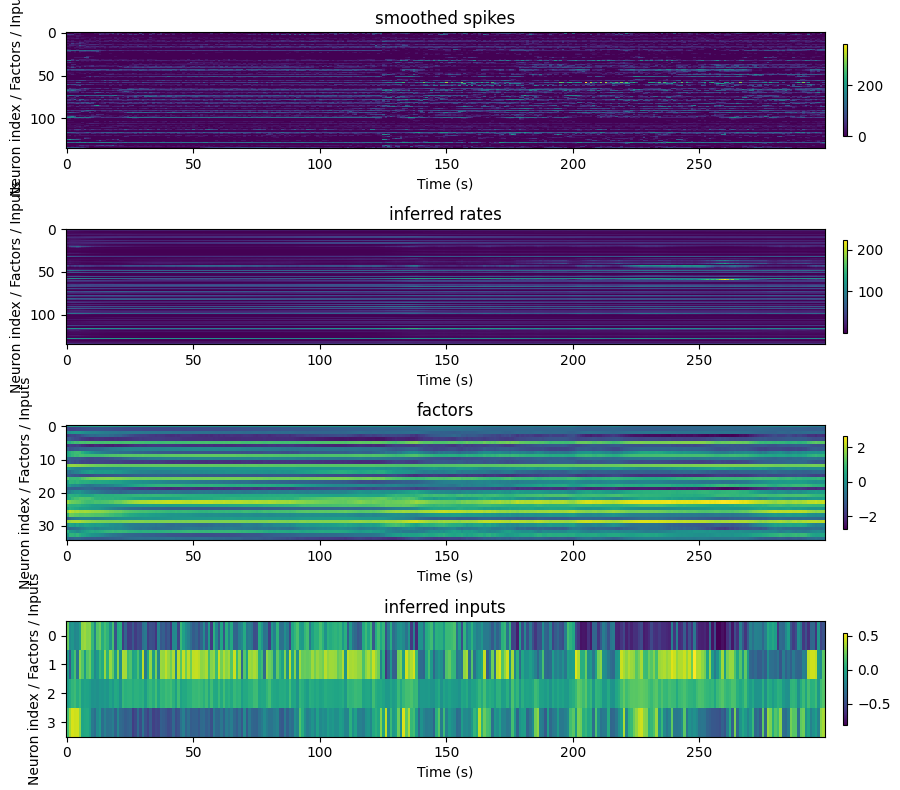

In [8]:
import matplotlib.pyplot as plt

# Visualize raw spikes, smoothed spikes, LFADS rates, and LFADS factors for a single trial
session = "PAG"
trial = 0
data = {
    "smoothed spikes": spikes[session][trial],
    "inferred rates": rates[session][trial],
    "factors": factors[session][trial],
    "inferred inputs": inferred_inputs[session][trial]
}

fig, axes = plt.subplots(nrows=4, figsize=(10, 8))
for ax, (name, data_val) in zip(axes, data.items()):
    im = ax.imshow(data_val.T, aspect='auto', interpolation='none', cmap='viridis')
    ax.set_xlabel('Time (s)')
    ax.set_ylabel('Neuron index / Factors / Inputs')
    ax.set_title(name)
    fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
plt.tight_layout()

As an additional check, we can plot the PSTHs of the LFADS rates to verify if they are comparable to the empirical PSTHs obtained using smoothed spikes.
For simplicity, we do this for a single session and 20 neurons below.

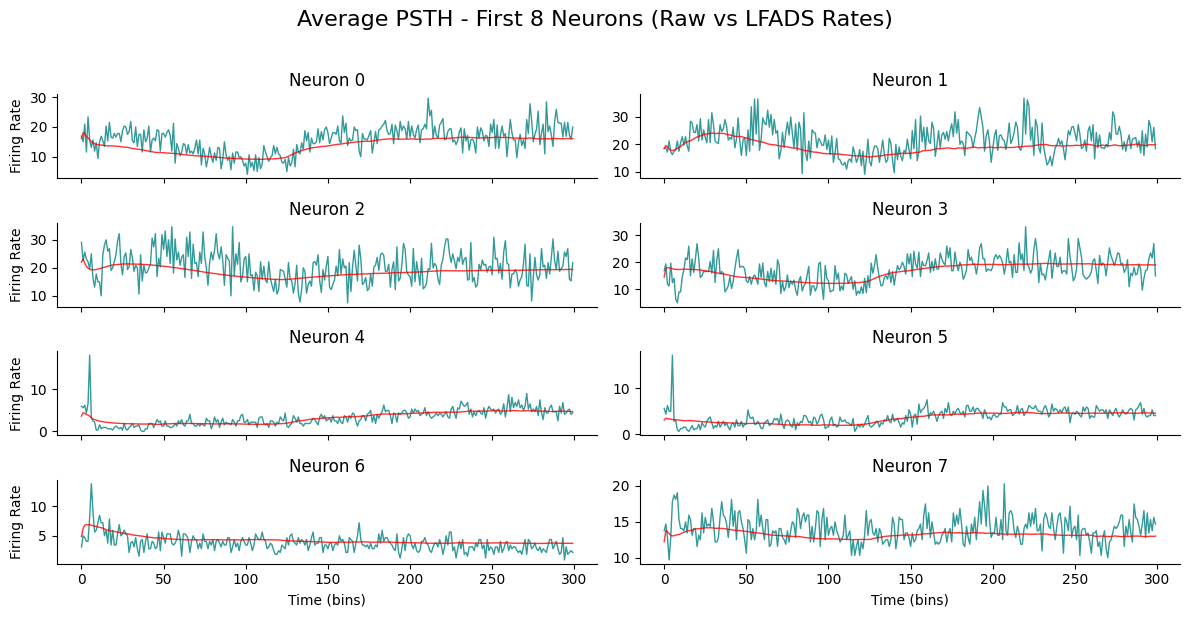

In [9]:
def plot_overlay_psths_first_8(spikes_data, rates_data, title):
    # Create a 4x2 grid to fit exactly 8 neurons
    fig, axes = plt.subplots(4, 2, figsize=(12, 6), sharex=True)
    
    # Flatten the axes array to easily iterate through all 8 subplots
    axes_flat = axes.flatten()
    
    for i in range(8):
        ax = axes_flat[i]
        
        # Calculate the mean across all trials for the i-th neuron
        spikes_mean_activity = np.mean(spikes_data[:, :, i], axis=0)
        rates_mean_activity = np.mean(rates_data[:, :, i], axis=0)
        
        ax.plot(spikes_mean_activity, color='teal', linewidth=1, alpha=0.8)
        ax.plot(rates_mean_activity, color='red', linewidth=1, alpha=0.8)
        ax.set_title(f"Neuron {i}", fontsize=12)
        
        # Clean up visual clutter
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add labels only to the bottom-most plots for a cleaner look
        if i >= 6:
            ax.set_xlabel("Time (bins)")
        if i % 2 == 0:
            ax.set_ylabel("Firing Rate")

    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

sess = 'PAG'
# Run the updated plotting function
plot_overlay_psths_first_8(spikes[sess], rates[sess], "Average PSTH - First 8 Neurons (Raw vs LFADS Rates)")

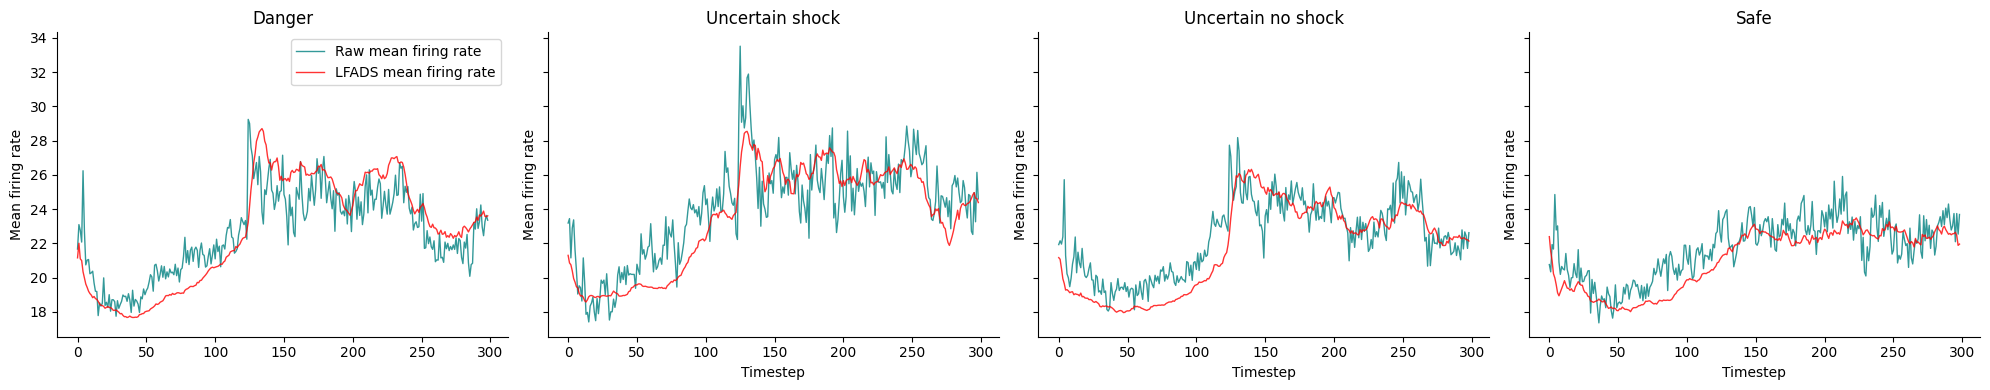

In [10]:
# Overlay firing rates for all neurons grouped by condition

def plot_denoised_rates_by_condition(spikes_data, rates_data, title):
    # Create a 2x2 grid to fit exactly 4 conditions
    fig, axes = plt.subplots(1, 4, figsize=(20, 4), sharex=True, sharey=True)
    
    # Flatten the axes array to easily iterate through all 4 subplots
    axes_flat = axes.flatten()
    conditions = ['Danger', 'Uncertain shock', 'Uncertain no shock', 'Safe']

    mean_spikes_danger = np.mean(np.mean(spikes_data[0:4, :, :], axis=2), axis=0)
    mean_spikes_unc_noshock = np.mean(np.mean(spikes_data[4:6, :, :], axis=2), axis=0)
    mean_spikes_unc_shock = np.mean(np.mean(spikes_data[6:11, :, :], axis=2), axis=0)
    mean_spikes_safety = np.mean(np.mean(spikes_data[11:15, :, :], axis=2), axis=0)

    spikes = [mean_spikes_danger, mean_spikes_unc_noshock, mean_spikes_unc_shock, mean_spikes_safety]

    mean_rates_danger = np.mean(np.mean(rates_data[0:4, :, :], axis=2), axis=0)
    mean_rates_unc_noshock = np.mean(np.mean(rates_data[4:6, :, :], axis=2), axis=0)
    mean_rates_unc_shock = np.mean(np.mean(rates_data[6:11, :, :], axis=2), axis=0)
    mean_rates_safety = np.mean(np.mean(rates_data[11:15, :, :], axis=2), axis=0)

    rates = [mean_rates_danger, mean_rates_unc_noshock, mean_rates_unc_shock, mean_rates_safety]
    
    for i in range(4):
        ax = axes_flat[i]
        
        ax.plot(spikes[i][1:], color='teal', linewidth=1, alpha=0.8, label='Raw mean firing rate')
        ax.plot(rates[i][1:], color='red', linewidth=1, alpha=0.8, label='LFADS mean firing rate')
        ax.set_title(conditions[i], fontsize=12)
        
        if i == 0:
            ax.legend()
        
        # Clean up visual clutter
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add labels only to the bottom-most plots for a cleaner look
        if i >= 1:
            ax.set_xlabel("Timestep")
        if i % 1 == 0:
            ax.set_ylabel("Mean firing rate")

    # plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

sess = 'PAG'
# Run the updated plotting function
plot_denoised_rates_by_condition(spikes[sess], rates[sess], "Average firing rates by condition (mean across all neurons)")

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

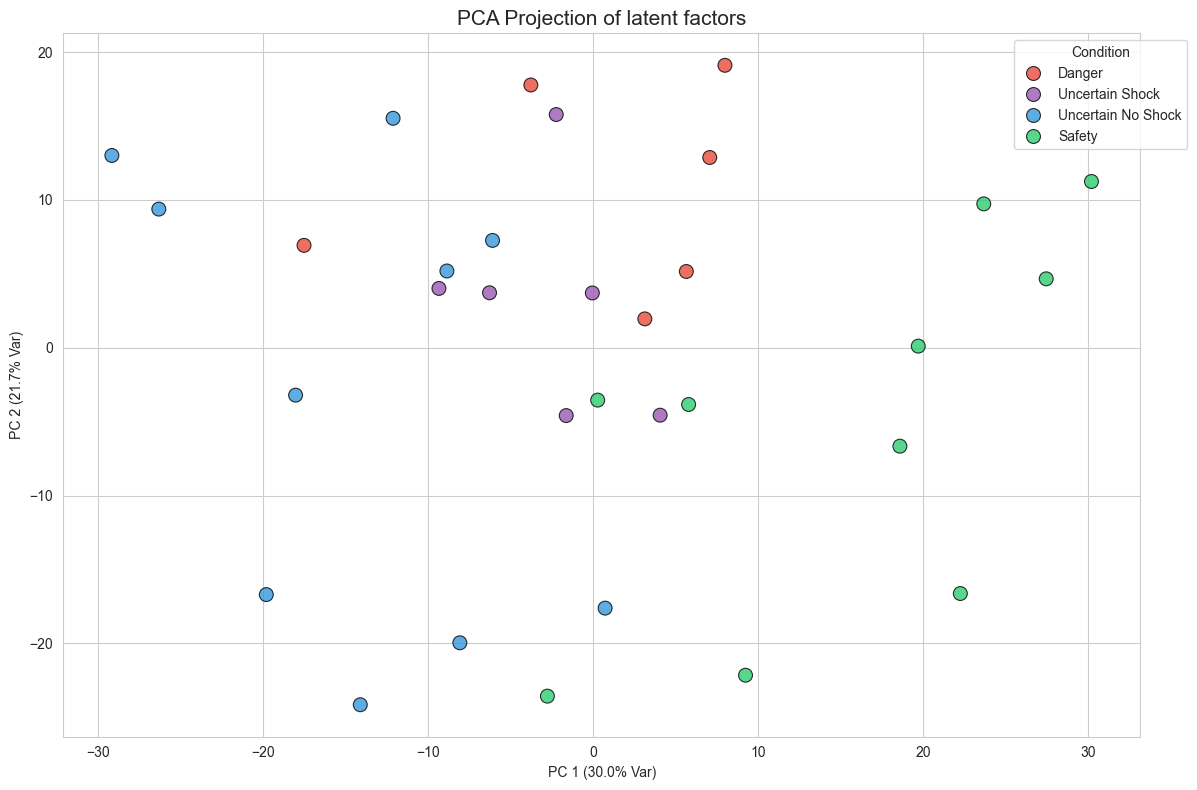

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

def plot_pca_stacked_inputs(data_array, title):
    """
    Reshapes data from (Trials, Time, Inputs) to (Trials * Inputs, Time)
    and performs PCA to compare with t-SNE results.
    """
    # 1. Reshape: (16, 400, 4) -> (16, 4, 400) -> (64, 400)
    n_trials, n_time, n_inputs = data_array.shape
    reshaped_data = data_array.reshape(n_trials, -1)

    # 2. Define labels for the 64 points (Same as your t-SNE script)
    base_conditions = (
        ['Danger'] * 6 + 
        ['Uncertain Shock'] * 6 + 
        ['Uncertain No Shock'] * 10 + 
        ['Safety'] * 10
    )

    # 3. Run PCA
    pca = PCA(n_components=2)
    pca_results = pca.fit_transform(reshaped_data)
    var_explained = pca.explained_variance_ratio_ * 100

    # 4. Visualization
    plt.figure(figsize=(12, 8))
    sns.set_style("whitegrid")
    
    palette = {
        'Danger': '#e74c3c', 
        'Uncertain Shock': '#9b59b6', 
        'Uncertain No Shock': '#3498db',
        'Safety': '#2ecc71'
    }

    sns.scatterplot(
        x=pca_results[:, 0], 
        y=pca_results[:, 1], 
        hue=base_conditions,
        palette=palette,
        s=100,
        alpha=0.8,
        edgecolor='black'
    )

    plt.title(title, fontsize=15)
    plt.xlabel(f'PC 1 ({var_explained[0]:.1f}% Var)')
    plt.ylabel(f'PC 2 ({var_explained[1]:.1f}% Var)')
    plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper right')
    plt.tight_layout()
    plt.show()

# Run the PCA comparison
plot_pca_stacked_inputs(factors['PAG'][:, 125:, :], 'PCA Projection of latent factors')

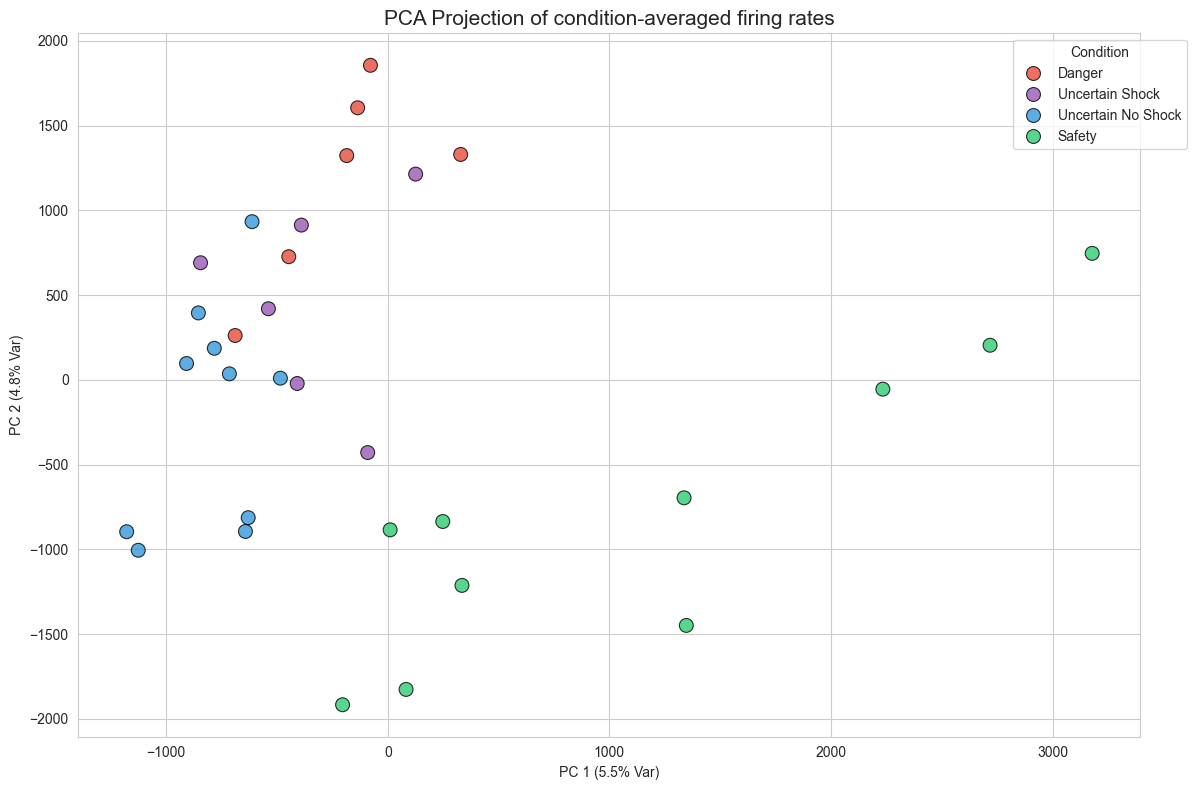

In [23]:
plot_pca_stacked_inputs(spikes['PAG'], 'PCA Projection of condition-averaged firing rates')

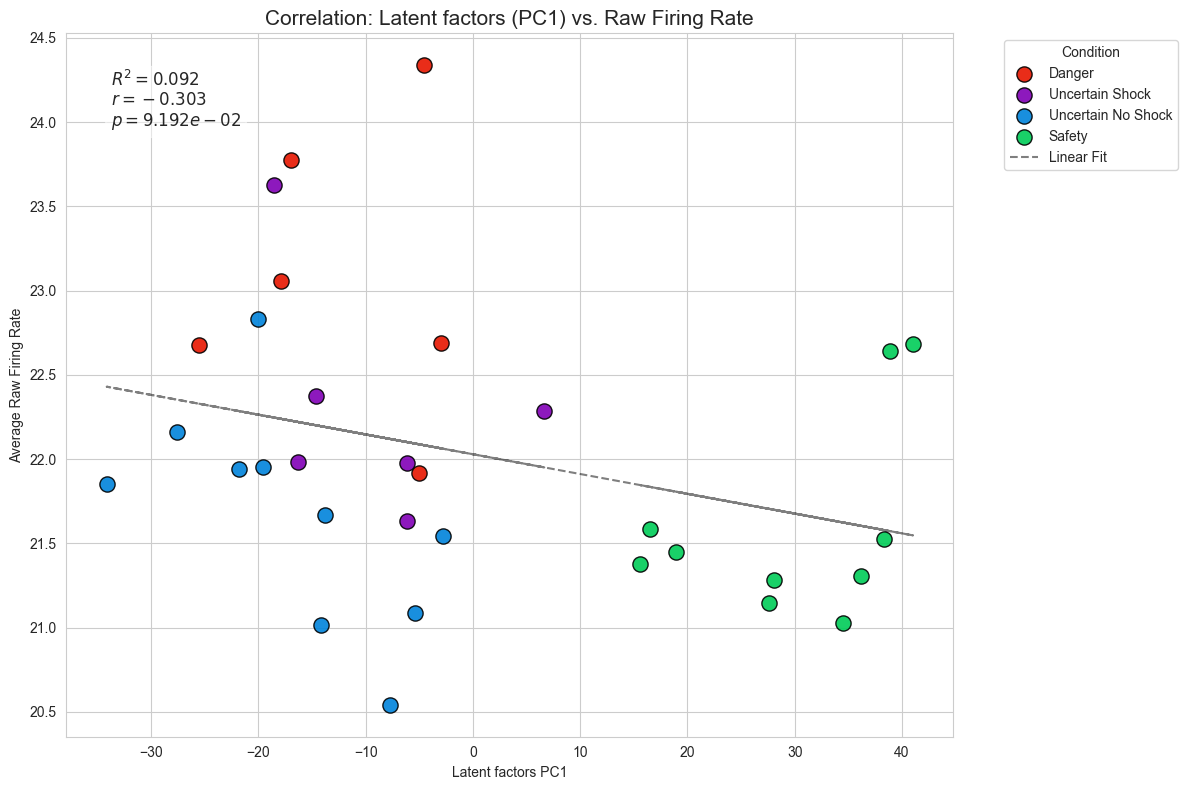

In [18]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy import stats # Added for correlation calculation
import matplotlib.colors as mcolors
import colorsys

def plot_pc1_vs_firing_rate_stats(raw_data, inferred_inputs):
    """
    Plots PC1 of Inferred Inputs against average firing rate 
    and displays the R^2 coefficient.
    """
    # 1. Prepare data
    n_trials, n_time, n_inputs = inferred_inputs.shape
    reshaped_inferred = inferred_inputs.reshape(n_trials, -1)
    avg_firing_rates = np.mean(raw_data, axis=(1, 2))

    # 2. Run PCA (PC1 only)
    pca = PCA(n_components=1)
    pc1_results = pca.fit_transform(reshaped_inferred).flatten()
    
    # 3. Calculate Statistics (Pearson r and R-squared)
    slope, intercept, r_value, p_value, std_err = stats.linregress(pc1_results, avg_firing_rates)
    r_squared = r_value**2

    # 4. Color logic (Darkest: first trial, Lightest: last trial)
    condition_counts = {'Danger': 6, 'Uncertain Shock': 6, 'Uncertain No Shock': 10, 'Safety': 10}
    base_palette = {'Danger': '#e74c3c', 'Uncertain Shock': '#9b59b6', 
                    'Uncertain No Shock': '#3498db', 'Safety': '#2ecc71'}

    labels, trial_colors = [], []
    for cond, count in condition_counts.items():
        h, s, v = colorsys.rgb_to_hsv(*mcolors.to_rgb(base_palette[cond]))
        for i in range(count):
            labels.append(cond)
            saturation_level = 1
            trial_colors.append(colorsys.hsv_to_rgb(h, saturation_level, v))

    # 5. Visualization
    plt.figure(figsize=(12, 8))
    sns.set_style("whitegrid")

    for i in range(n_trials):
        plt.scatter(
            pc1_results[i], avg_firing_rates[i], 
            color=trial_colors[i], s=120, edgecolor='black', alpha=0.9,
            label=labels[i] if labels[i] not in plt.gca().get_legend_handles_labels()[1] else ""
        )

    # Plot Regression Line
    line = slope * pc1_results + intercept
    plt.plot(pc1_results, line, color='black', linestyle='--', alpha=0.5, label='Linear Fit')

    # Add Stats Text Box
    stats_text = f"$R^2 = {r_squared:.3f}$\n$r = {r_value:.3f}$\n$p = {p_value:.3e}$"
    plt.gca().text(0.05, 0.95, stats_text, transform=plt.gca().transAxes, 
                   fontsize=12, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.5))

    plt.title('Correlation: Latent factors (PC1) vs. Raw Firing Rate', fontsize=15)
    plt.xlabel('Latent factors PC1')
    plt.ylabel('Average Raw Firing Rate')
    plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Example usage:
plot_pc1_vs_firing_rate_stats(spikes['PAG'], factors['PAG'])
# plot_pc1_vs_firing_rate_stats(spikes['PAG'], spikes['PAG'])

/tmp/ipykernel_2464729/3410143571.py:31: NearConstantInputWarning: An input array is nearly constant; the computed correlation coefficient may be inaccurate.
  r, p = stats.pearsonr(pc_scores[:, i], avg_firing_rates)


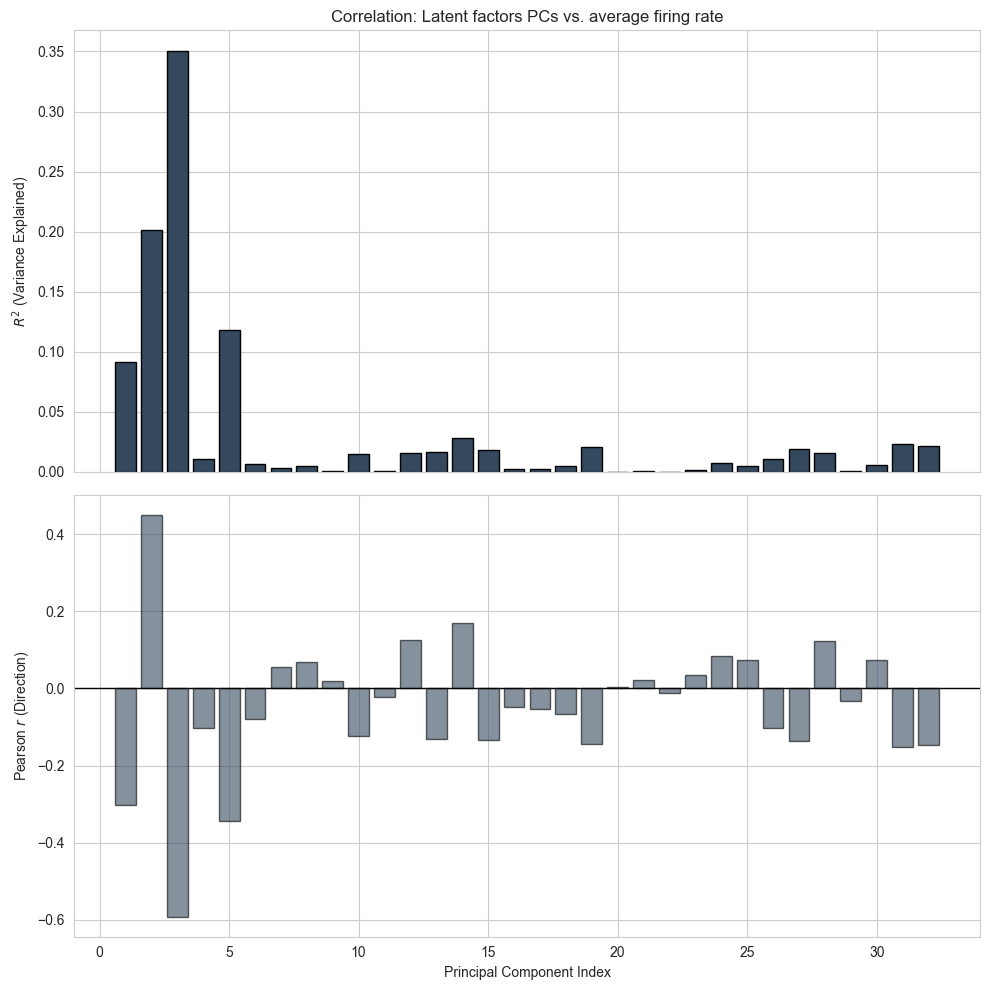

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from scipy import stats

def check_all_pc_correlations(raw_data, inferred_inputs, n_pcs=10):
    """
    Computes correlation between the first N Principal Components 
    of inferred inputs and the average raw firing rate.
    """
    # 1. Prepare Data
    n_trials, n_time, n_inputs = inferred_inputs.shape
    reshaped_inferred = inferred_inputs.reshape(n_trials, -1)
    
    # Average firing rate per trial
    avg_firing_rates = np.mean(raw_data, axis=(1, 2))

    # 2. Run PCA for multiple components
    # Ensure n_pcs doesn't exceed the number of trials or features
    n_pcs = min(n_pcs, n_trials, reshaped_inferred.shape[1])
    pca = PCA(n_components=n_pcs)
    pc_scores = pca.fit_transform(reshaped_inferred)
    
    # 3. Calculate Correlations for each PC
    rs = []
    p_values = []
    r_squared_values = []

    for i in range(n_pcs):
        r, p = stats.pearsonr(pc_scores[:, i], avg_firing_rates)
        rs.append(r)
        p_values.append(p)
        r_squared_values.append(r**2)

    # 4. Visualization
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10), sharex=True)
    sns.set_style("ticks")

    # Plot R-squared (Strength of Relationship)
    colors = ['#34495e']
    ax1.bar(range(1, n_pcs + 1), r_squared_values, color=colors, edgecolor='black')
    ax1.set_ylabel('$R^2$ (Variance Explained)')
    ax1.set_title('Correlation: Latent factors PCs vs. average firing rate')
    
    # Plot Pearson r (Direction of Relationship)
    ax2.bar(range(1, n_pcs + 1), rs, color=colors, edgecolor='black', alpha=0.6)
    ax2.axhline(0, color='black', lw=1)
    ax2.set_ylabel('Pearson $r$ (Direction)')
    ax2.set_xlabel('Principal Component Index')

    plt.tight_layout()
    plt.show()

    return {"r_squared": r_squared_values, "p_values": p_values}

# Example call:
results = check_all_pc_correlations(spikes['PAG'], factors['PAG'], n_pcs=40)

# Inferred inputs analysis

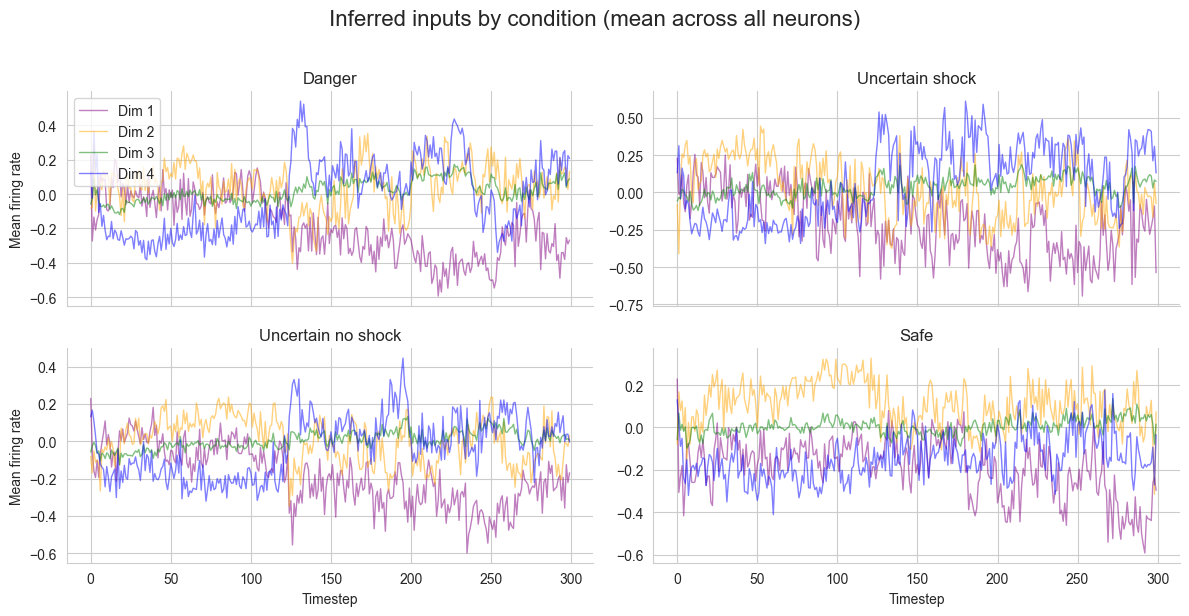

In [13]:
# plot inferred inputs for each condition

def plot_inferred_inputs_by_condition(input_data, title):
    # Create a 2x2 grid to fit exactly 4 conditions
    fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
    conditions = ['Danger', 'Uncertain shock', 'Uncertain no shock', 'Safe']
    
    # Flatten the axes array to easily iterate through all 4 subplots
    axes_flat = axes.flatten()

    inputs_dim0_danger = np.mean(input_data[0:4, :, 0:1], axis=0)
    inputs_dim0_unc_noshock = np.mean(input_data[4:6, :, 0:1], axis=0)
    inputs_dim0_unc_shock = np.mean(input_data[6:11, :, 0:1], axis=0)
    inputs_dim0_safety = np.mean(input_data[11:15, :, 0:1], axis=0)

    inputs_dim0 = [inputs_dim0_danger, inputs_dim0_unc_noshock, inputs_dim0_unc_shock, inputs_dim0_safety]

    inputs_dim1_danger = np.mean(input_data[0:4, :, 1:2], axis=0)
    inputs_dim1_unc_noshock = np.mean(input_data[4:6, :, 1:2], axis=0)
    inputs_dim1_unc_shock = np.mean(input_data[6:11, :, 1:2], axis=0)
    inputs_dim1_safety = np.mean(input_data[11:15, :, 1:2], axis=0)

    inputs_dim1 = [inputs_dim1_danger, inputs_dim1_unc_noshock, inputs_dim1_unc_shock, inputs_dim1_safety]

    inputs_dim2_danger = np.mean(input_data[0:4, :, 2:3], axis=0)
    inputs_dim2_unc_noshock = np.mean(input_data[4:6, :, 2:3], axis=0)
    inputs_dim2_unc_shock = np.mean(input_data[6:11, :, 2:3], axis=0)
    inputs_dim2_safety = np.mean(input_data[11:15, :, 2:3], axis=0)

    inputs_dim2 = [inputs_dim2_danger, inputs_dim2_unc_noshock, inputs_dim2_unc_shock, inputs_dim2_safety]

    inputs_dim3_danger = np.mean(input_data[0:4, :, 3:4], axis=0)
    inputs_dim3_unc_noshock = np.mean(input_data[4:6, :, 3:4], axis=0)
    inputs_dim3_unc_shock = np.mean(input_data[6:11, :, 3:4], axis=0)
    inputs_dim3_safety = np.mean(input_data[11:15, :, 3:4], axis=0)

    inputs_dim3 = [inputs_dim3_danger, inputs_dim3_unc_noshock, inputs_dim3_unc_shock, inputs_dim3_safety]
    
    for i in range(4):
        ax = axes_flat[i]
        
        ax.plot(inputs_dim0[i], color='purple', linewidth=1, alpha=0.5, label='Dim 1')
        ax.plot(inputs_dim1[i], color='orange', linewidth=1, alpha=0.5, label='Dim 2')
        ax.plot(inputs_dim2[i], color='green', linewidth=1, alpha=0.5, label='Dim 3')
        ax.plot(inputs_dim3[i], color='blue', linewidth=1, alpha=0.5, label='Dim 4')
        ax.set_title(conditions[i], fontsize=12)
        
        if i == 0:
            ax.legend()
        
        # Clean up visual clutter
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add labels only to the bottom-most plots for a cleaner look
        if i >= 2:
            ax.set_xlabel("Timestep")
        if i % 2 == 0:
            ax.set_ylabel("Mean firing rate")

    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

sess = 'PAG'
# Run the updated plotting function
plot_inferred_inputs_by_condition(inferred_inputs[sess], "Inferred inputs by condition (mean across all neurons)")

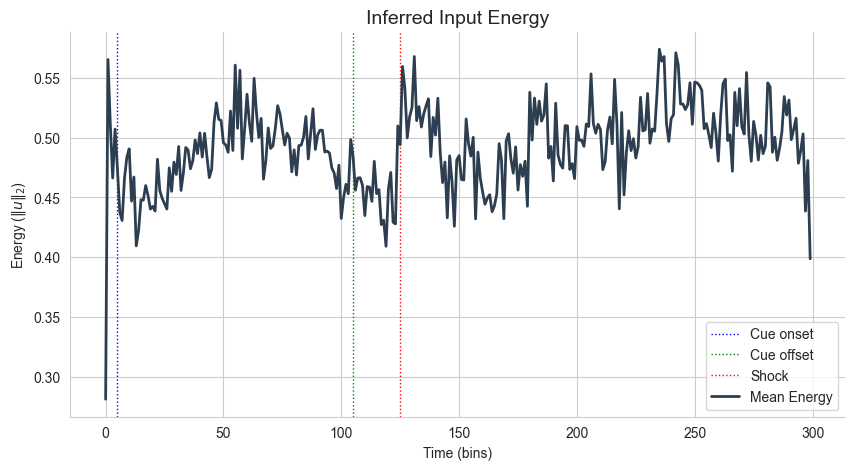

In [14]:
def plot_input_energy(inputs, title="Inferred Input Energy", axes=None):
    """
    Calculates and plots the L2 norm (energy) of inferred inputs over time.
    
    Parameters:
        inputs: np.array of shape (n_trials, n_time, n_inputs)
        title: string for the plot title
        axes: optional matplotlib axis for subplot integration
    """
    # 1. Calculate Energy: Square the inputs, sum across dimensions, then sqrt
    # shape results in (n_trials, n_time)
    energy = np.linalg.norm(inputs, axis=2)
    
    # 2. Calculate mean and standard error across trials
    mean_energy = np.mean(energy, axis=0)
    std_error = np.std(energy, axis=0) / np.sqrt(inputs.shape[0])
    time_points = np.arange(inputs.shape[1])

    # 3. Plotting
    if axes is None:
        fig, ax = plt.subplots(figsize=(10, 5))
    else:
        ax = axes

    ax.axvline(5, color='blue', linestyle=':', linewidth=1, label='Cue onset')
    ax.axvline(105, color='green', linestyle=':', linewidth=1, label='Cue offset')
    ax.axvline(125, color='red', linestyle=':', linewidth=1, label='Shock')
    ax.plot(time_points, mean_energy, color='#2c3e50', lw=2, label='Mean Energy')


    ax.set_title(title, fontsize=14)
    ax.set_xlabel("Time (bins)")
    ax.set_ylabel("Energy ($\|u\|_2$)")
    ax.legend()
    sns.despine(ax=ax)
    
    if axes is None:
        plt.show()

# Example usage:
plot_input_energy(inferred_inputs['PAG'])

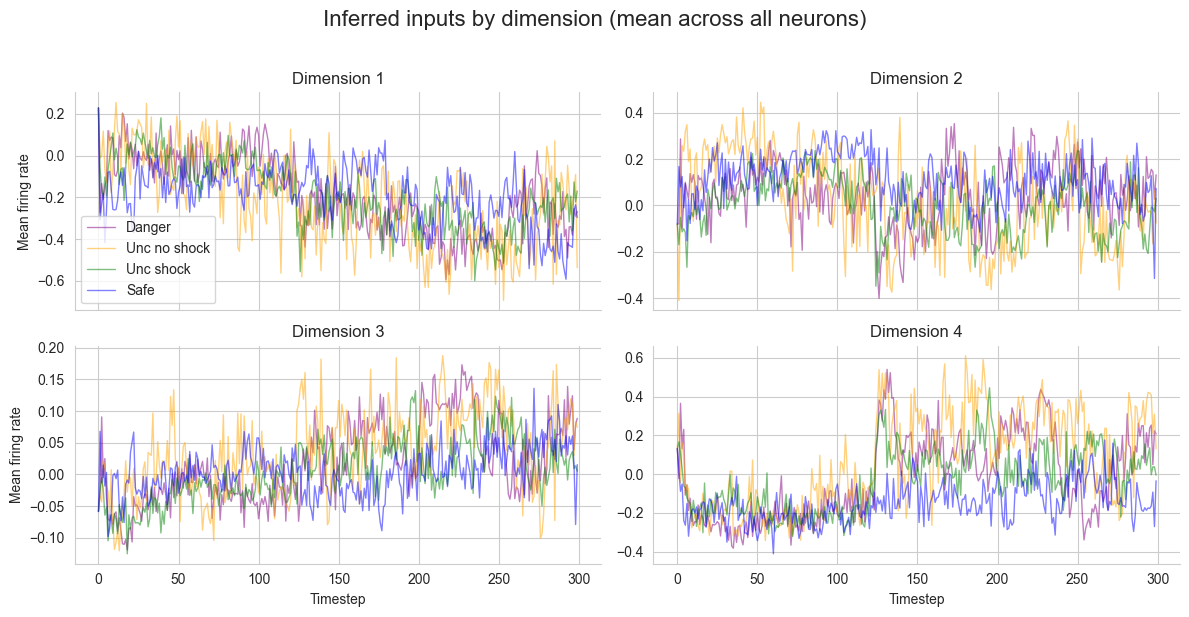

In [15]:
# plot 4 conditions for each dimension of inferred inputs

def plot_inferred_inputs_by_dimension(input_data, title):
    # Create a 2x2 grid to fit exactly 4 dimensions
    fig, axes = plt.subplots(2, 2, figsize=(12, 6), sharex=True)
    dimensions = ['Dimension 1', 'Dimension 2', 'Dimension 3', 'Dimension 4']
    
    # Flatten the axes array to easily iterate through all 4 subplots
    axes_flat = axes.flatten()

    inputs_dim0_danger = np.mean(input_data[0:4, :, 0:1], axis=0)
    inputs_dim0_unc_noshock = np.mean(input_data[4:6, :, 0:1], axis=0)
    inputs_dim0_unc_shock = np.mean(input_data[6:11, :, 0:1], axis=0)
    inputs_dim0_safety = np.mean(input_data[11:15, :, 0:1], axis=0)

    inputs_dim1_danger = np.mean(input_data[0:4, :, 1:2], axis=0)
    inputs_dim1_unc_noshock = np.mean(input_data[4:6, :, 1:2], axis=0)
    inputs_dim1_unc_shock = np.mean(input_data[6:11, :, 1:2], axis=0)
    inputs_dim1_safety = np.mean(input_data[11:15, :, 1:2], axis=0)

    inputs_dim2_danger = np.mean(input_data[0:4, :, 2:3], axis=0)
    inputs_dim2_unc_noshock = np.mean(input_data[4:6, :, 2:3], axis=0)
    inputs_dim2_unc_shock = np.mean(input_data[6:11, :, 2:3], axis=0)
    inputs_dim2_safety = np.mean(input_data[11:15, :, 2:3], axis=0)

    inputs_dim3_danger = np.mean(input_data[0:4, :, 3:4], axis=0)
    inputs_dim3_unc_noshock = np.mean(input_data[4:6, :, 3:4], axis=0)
    inputs_dim3_unc_shock = np.mean(input_data[6:11, :, 3:4], axis=0)
    inputs_dim3_safety = np.mean(input_data[11:15, :, 3:4], axis=0)

    danger = [inputs_dim0_danger, inputs_dim1_danger, inputs_dim2_danger, inputs_dim3_danger]
    unc_noshock = [inputs_dim0_unc_noshock, inputs_dim1_unc_noshock, inputs_dim2_unc_noshock, inputs_dim3_unc_noshock]
    unc_shock = [inputs_dim0_unc_shock, inputs_dim1_unc_shock, inputs_dim2_unc_shock, inputs_dim3_unc_shock]
    safety = [inputs_dim0_safety, inputs_dim1_safety, inputs_dim2_safety, inputs_dim3_safety]

    for i in range(4):
        ax = axes_flat[i]
        
        ax.plot(danger[i], color='purple', linewidth=1, alpha=0.5, label='Danger')
        ax.plot(unc_noshock[i], color='orange', linewidth=1, alpha=0.5, label='Unc no shock')
        ax.plot(unc_shock[i], color='green', linewidth=1, alpha=0.5, label='Unc shock')
        ax.plot(safety[i], color='blue', linewidth=1, alpha=0.5, label='Safe')
        ax.set_title(dimensions[i], fontsize=12)
        
        if i == 0:
            ax.legend()
        
        # Clean up visual clutter
        ax.spines['top'].set_visible(False)
        ax.spines['right'].set_visible(False)
        
        # Add labels only to the bottom-most plots for a cleaner look
        if i >= 2:
            ax.set_xlabel("Timestep")
        if i % 2 == 0:
            ax.set_ylabel("Mean firing rate")

    plt.suptitle(title, fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

sess = 'PAG'
# Run the updated plotting function
plot_inferred_inputs_by_dimension(inferred_inputs[sess], "Inferred inputs by dimension (mean across all neurons)")

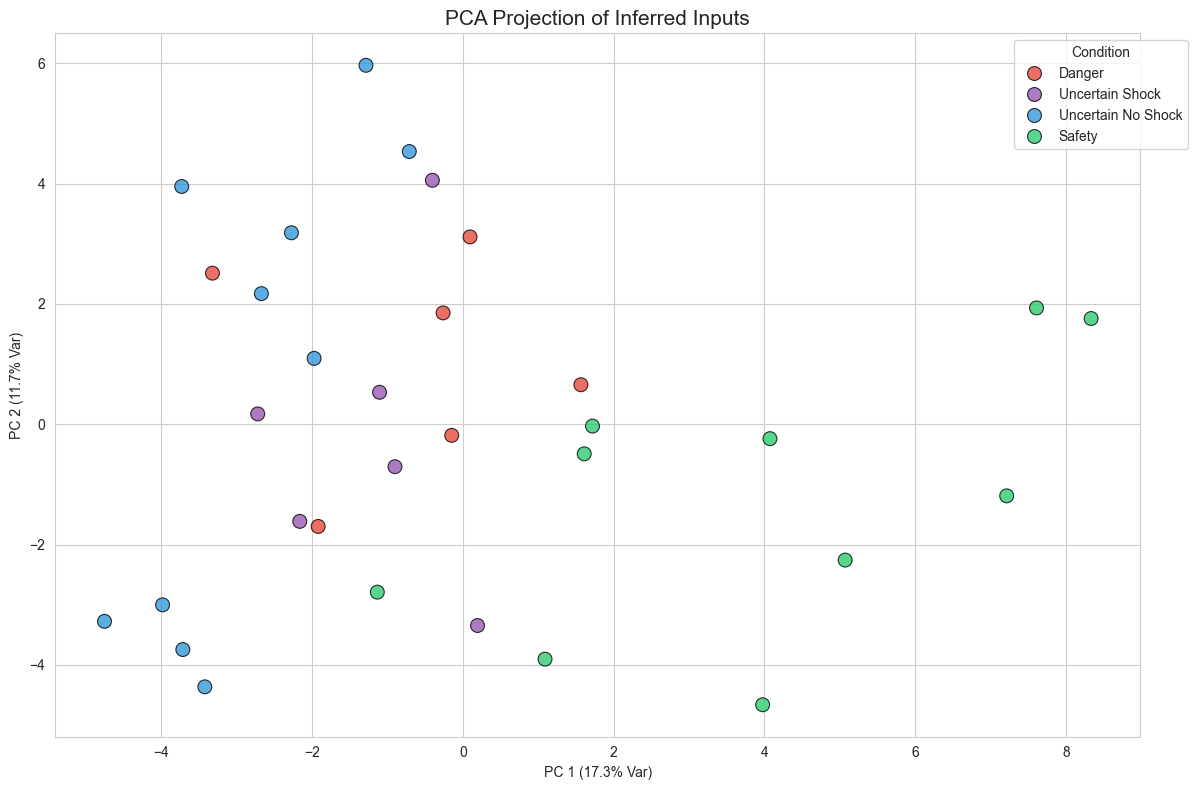

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

def plot_pca_stacked_inputs(data_array):
    """
    Reshapes data from (Trials, Time, Inputs) to (Trials * Inputs, Time)
    and performs PCA to compare with t-SNE results.
    """
    # 1. Reshape: (16, 400, 4) -> (16, 4, 400) -> (64, 400)
    n_trials, n_time, n_inputs = data_array.shape
    reshaped_data = data_array.reshape(n_trials, -1)

    # 2. Define labels for the 64 points (Same as your t-SNE script)
    base_conditions = (
        ['Danger'] * 6 + 
        ['Uncertain Shock'] * 6 + 
        ['Uncertain No Shock'] * 10 + 
        ['Safety'] * 10
    )

    # 3. Run PCA
    pca = PCA(n_components=2)
    pca_results = pca.fit_transform(reshaped_data)
    var_explained = pca.explained_variance_ratio_ * 100

    # 4. Visualization
    plt.figure(figsize=(12, 8))
    sns.set_style("whitegrid")
    
    palette = {
        'Danger': '#e74c3c', 
        'Uncertain Shock': '#9b59b6', 
        'Uncertain No Shock': '#3498db',
        'Safety': '#2ecc71'
    }

    sns.scatterplot(
        x=pca_results[:, 0], 
        y=pca_results[:, 1], 
        hue=base_conditions,
        palette=palette,
        s=100,
        alpha=0.8,
        edgecolor='black'
    )

    plt.title('PCA Projection of Inferred Inputs', fontsize=15)
    plt.xlabel(f'PC 1 ({var_explained[0]:.1f}% Var)')
    plt.ylabel(f'PC 2 ({var_explained[1]:.1f}% Var)')
    plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper right')
    plt.tight_layout()
    plt.show()

# Run the PCA comparison
plot_pca_stacked_inputs(inferred_inputs['PAG'][:, :, :])

# Initial conditions analysis

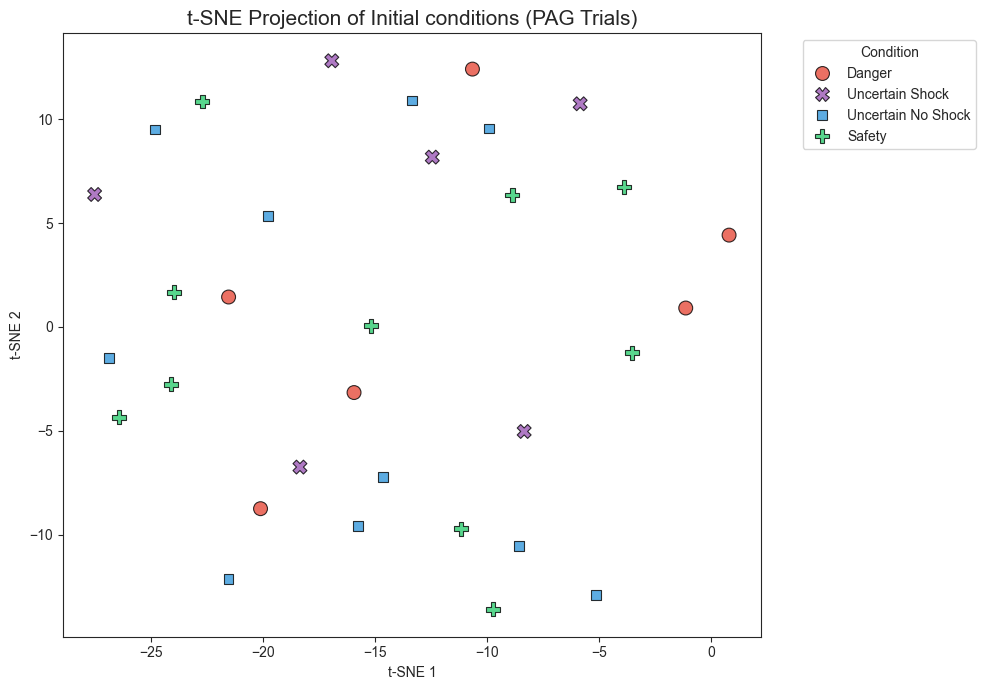

In [17]:
# t-SNE clustering of initial conditions

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.manifold import TSNE

def plot_tsne_init_cond(data_array):
    """
    Projects trial data to 2D using t-SNE and colors by condition.
    data_array: np.ndarray of shape (n_trials, d_initial_condition) = (16, 64)
    """

    # 1. Define the conditions based on your trial counts
    # 4 Danger, 2 Uncertain Shock, 6 Uncertain No Shock, 4 Safety
    conditions = (
        ['Danger'] * 6 + 
        ['Uncertain Shock'] * 6 + 
        ['Uncertain No Shock'] * 10 + 
        ['Safety'] * 10
    )

    # 2. Run t-SNE
    # perplexity should be smaller than n_samples (32)
    tsne = TSNE(n_components=2, perplexity=10, random_state=42, init='pca', learning_rate='auto')
    tsne_results = tsne.fit_transform(data_array)

    # 3. Visualization
    plt.figure(figsize=(10, 7))
    sns.set_style("ticks")
    
    # Custom color palette for conditions
    palette = {
        'Danger': '#e74c3c',            # Red
        'Uncertain Shock': '#9b59b6',   # Purple
        'Uncertain No Shock': '#3498db',# Blue
        'Safety': '#2ecc71'             # Green
    }

    sns.scatterplot(
        x=tsne_results[:, 0], 
        y=tsne_results[:, 1], 
        hue=conditions,
        palette=palette,
        s=100,
        style=conditions,
        edgecolor='black',
        alpha=0.8
    )

    plt.title('t-SNE Projection of Initial conditions (PAG Trials)', fontsize=15)
    plt.xlabel('t-SNE 1')
    plt.ylabel('t-SNE 2')
    plt.legend(title='Condition', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()

# Example usage:
plot_tsne_init_cond(initial_conditions['PAG'])